# BUAN 6337.002 Predictive Analytics for Data Science - Urban Noise Prediction in Texas
Group 5 - ESHA PANDEY(EXP240010),TAEJASVI MULAKALA(TXM230050),TEJAS 
SHRIPAD DESHKULKARNI(TXD230017),PIN-YU CHU(PXC240003)

## Import data
- Generate the longitude and latitude data by districts

In [1]:
import pandas as pd
import numpy as np

# Load the UrbanSound8K metadata CSV
data = pd.read_csv("UrbanSound8K.csv")

# Define 10 real districts in Texas with coordinates
districts_tx = {
    'Austin': (30.2672, -97.7431),
    'Dallas': (32.7767, -96.7970),
    'Houston': (29.7604, -95.3698),
    'San Antonio': (29.4241, -98.4936),
    'El Paso': (31.7619, -106.4850),
    'Fort Worth': (32.7555, -97.3308),
    'Plano': (33.0198, -96.6989),
    'Lubbock': (33.5779, -101.8552),
    'Corpus Christi': (27.8006, -97.3964),
    'Arlington': (32.7357, -97.1081)
}

# Randomly assign each audio clip to one of the districts
np.random.seed(42)  # For reproducibility
district_list = list(districts_tx.keys())
data['district'] = np.random.choice(district_list, size=len(data))

# Add latitude and longitude columns using the mapping
data['latitude'] = data['district'].map(lambda x: districts_tx[x][0])
data['longitude'] = data['district'].map(lambda x: districts_tx[x][1])

# Save the new dataset with location info
data.to_csv("UrbanSound8K_with_TexasDistricts.csv", index=False)

print("Dataset saved as 'UrbanSound8K_with_TexasDistricts.csv'")

Dataset saved as 'UrbanSound8K_with_TexasDistricts.csv'


- Create the simulated average decibel based on the types of noise

In [3]:
import pandas as pd
import numpy as np

# Load your existing dataset (with Texas districts)
df = pd.read_csv("UrbanSound8K_with_TexasDistricts.csv")

# Define simulated average decibel levels for each sound class
decibel_map = {
    'gun_shot': 125,
    'jackhammer': 100,
    'siren': 110,
    'drilling': 95,
    'dog_bark': 85,
    'car_horn': 90,
    'engine_idling': 75,
    'air_conditioner': 65,
    'children_playing': 70,
    'street_music': 80
}

# Map decibel values to each row based on its 'class'
df['decibel'] = df['class'].map(decibel_map)

# STEP 4: Simulate time of day (hour: 0 to 23)
np.random.seed(42)  # For reproducibility
df['hour'] = np.random.randint(0, 24, size=len(df))

# STEP 5: Save the enhanced dataset to a new CSV
df.to_csv("UrbanSound8K_with_TexasDistricts_and_dB_Time.csv", index=False)

print("New dataset saved as 'UrbanSound8K_with_TexasDistricts_and_dB_Time.csv'")

New dataset saved as 'UrbanSound8K_with_TexasDistricts_and_dB_Time.csv'


- Insert 7-day information to distinguish which day the noise occurred

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("UrbanSound8K_with_TexasDistricts_and_dB_Time.csv")

# Add a new 'day' column randomly from 1 to 7
np.random.seed(42)
df['day'] = np.random.randint(1, 8, size=len(df))

# sort for time-series 
df = df.sort_values(by=['district', 'day', 'hour']).reset_index(drop=True)

# Save it
df.to_csv("UrbanSound8K_7days_Simulated.csv", index=False)
print("7-day version created using random day assignment.")

7-day version created using random day assignment.


- Define the time when the noise occurred

In [7]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("UrbanSound8K_7days_Simulated.csv")

# Define realistic hour ranges for each sound class
hour_distribution = {
    'jackhammer': list(range(8, 18)),         # 8 AM to 5 PM
    'siren': list(range(0, 24)),              # Anytime
    'street_music': list(range(16, 22)),      # 4 PM to 9 PM
    'dog_bark': [6, 7, 8, 12, 18, 19, 20],    # Morning & evening
    'children_playing': [10, 11, 12, 15, 16, 17],
    'air_conditioner': list(range(9, 23)),    # Daytime to late evening
    'engine_idling': [6, 7, 8, 17, 18, 19],   # Rush hours
    'drilling': [9, 10, 11, 13, 14, 15],      # Typical work hours
    'gun_shot': [0, 1, 2, 22, 23],            # Late night/early morning
    'car_horn': list(range(7, 22)),           # Urban movement times
}

# Function to assign a realistic hour based on class
def assign_hour_by_class(row):
    sound_class = row['class']
    hours = hour_distribution.get(sound_class, list(range(24)))
    return np.random.choice(hours)

# Apply the function to update the 'hour' column
df['hour'] = df.apply(assign_hour_by_class, axis=1)

# Save the normalized dataset
df.to_csv("UrbanSound8K_7days_HourNormalized.csv", index=False)
print("Hour normalization complete. File saved as 'UrbanSound8K_7days_HourNormalized.csv'")

Hour normalization complete. File saved as 'UrbanSound8K_7days_HourNormalized.csv'


In [80]:
import pandas as pd

# Load the dataset
df = pd.read_csv("UrbanSound8K_7days_HourNormalized.csv")

# View basic structure
print(df.shape)
print(df.info())
display(df.head())

(8732, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8732 entries, 0 to 8731
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   slice_file_name  8732 non-null   object 
 1   fsID             8732 non-null   int64  
 2   start            8732 non-null   float64
 3   end              8732 non-null   float64
 4   salience         8732 non-null   int64  
 5   fold             8732 non-null   int64  
 6   classID          8732 non-null   int64  
 7   class            8732 non-null   object 
 8   district         8732 non-null   object 
 9   latitude         8732 non-null   float64
 10  longitude        8732 non-null   float64
 11  decibel          8732 non-null   int64  
 12  hour             8732 non-null   int64  
 13  day              8732 non-null   int64  
dtypes: float64(4), int64(7), object(3)
memory usage: 955.2+ KB
None


,slice_file_name,fsID,start,end,salience,fold,classID,class,district,latitude,longitude,decibel,hour,day
0,113205-5-1-7.wav,113205,30.540000,34.540000,1,1,5,engine_idling,Arlington,32.7357,-97.1081,75,18,1
1,122199-3-1-1.wav,122199,15.147059,19.147059,2,8,3,dog_bark,Arlington,32.7357,-97.1081,85,20,1
2,123399-2-0-5.wav,123399,2.500000,6.500000,1,3,2,children_playing,Arlington,32.7357,-97.1081,70,10,1
3,158608-8-0-10.wav,158608,12.309707,16.309707,2,4,8,siren,Arlington,32.7357,-97.1081,110,15,1
4,162103-0-0-6.wav,162103,3.000000,7.000000,1,8,0,air_conditioner,Arlington,32.7357,-97.1081,65,20,1


## Data Pre-processing
- Tackle null values

In [82]:
# Drop columns that are not useful for modeling
df = df.drop(columns=['slice_file_name', 'fsID', 'start', 'end', 'fold'])

# Check for duplicates
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 salience     0
classID      0
class        0
district     0
latitude     0
longitude    0
decibel      0
hour         0
day          0
dtype: int64


### Statistical Summary

In [84]:
# Summary statistics
print(df.describe())

# Sound class distribution
print("\nClass distribution:\n", df['class'].value_counts())

# Average dB per district
print("\nAvg dB by district:\n", df.groupby('district')['decibel'].mean())

          salience      classID     latitude    longitude      decibel  \
count  5570.000000  5570.000000  5570.000000  5570.000000  5570.000000   
mean      1.421544     4.535009    31.397306   -98.500960    87.843806   
std       0.493851     3.048588     1.830011     3.089533    16.890924   
min       1.000000     0.000000    27.800600  -106.485000    65.000000   
25%       1.000000     2.000000    29.760400   -98.493600    75.000000   
50%       1.000000     4.000000    32.735700   -97.330800    85.000000   
75%       2.000000     7.000000    32.776700   -96.797000   100.000000   
max       2.000000     9.000000    33.577900   -95.369800   125.000000   

              hour          day  
count  5570.000000  5570.000000  
mean     13.494075     4.012567  
std       5.393083     2.006146  
min       0.000000     1.000000  
25%      10.000000     2.000000  
50%      14.000000     4.000000  
75%      18.000000     6.000000  
max      23.000000     7.000000  

Class distribution:
 class

- Frequency Histogram of Decibel Level

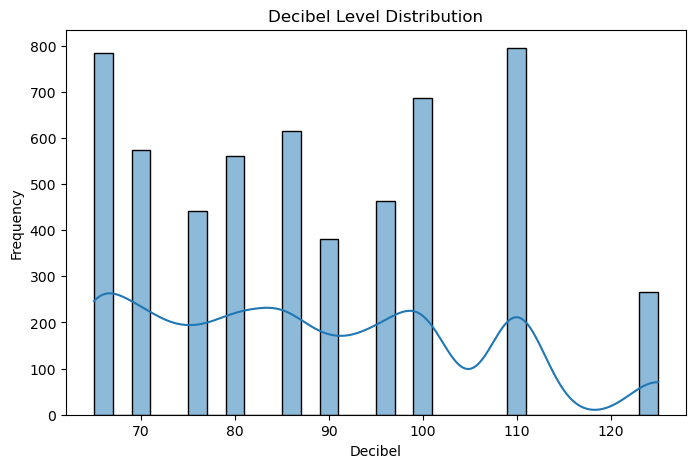

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Distribution of Decibel Levels
plt.figure(figsize=(8, 5))
sns.histplot(df['decibel'], bins=30, kde=True)
plt.title("Decibel Level Distribution")
plt.xlabel("Decibel")
plt.ylabel("Frequency")
plt.show()

- Correlation heatmap between all variables

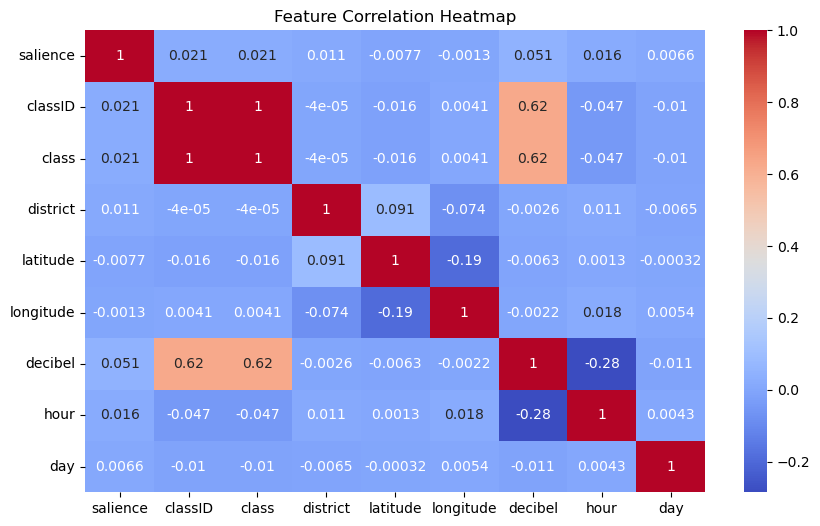

In [88]:
from sklearn.preprocessing import LabelEncoder

# Creating a copy for safe encoding
df_encoded = df.copy()

# Encode 'class' and 'district' to numeric
le_class = LabelEncoder()
le_district = LabelEncoder()

df_encoded['class'] = le_class.fit_transform(df_encoded['class'])
df_encoded['district'] = le_district.fit_transform(df_encoded['district'])

import seaborn as sns
import matplotlib.pyplot as plt

# 3. Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

- Line chart of average decibel within a day

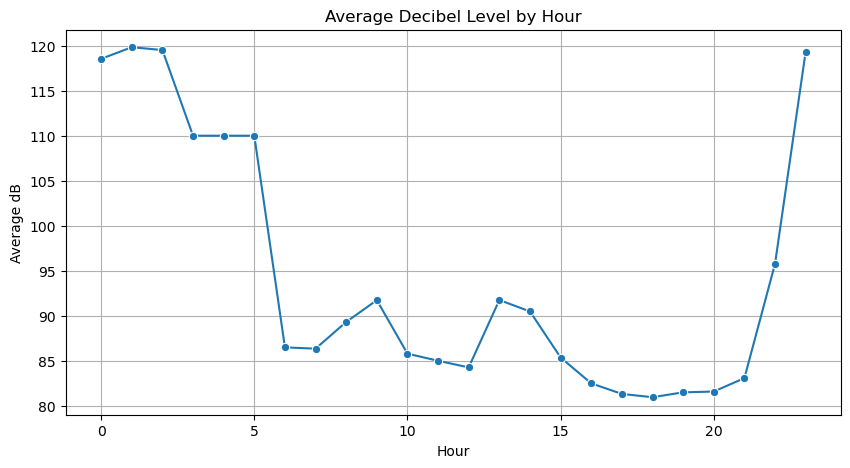

In [90]:
# 4. Lineplot: Average Decibel by Hour
avg_by_hour = df.groupby('hour')['decibel'].mean().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=avg_by_hour, x='hour', y='decibel', marker="o")
plt.title("Average Decibel Level by Hour")
plt.xlabel("Hour")
plt.ylabel("Average dB")
plt.grid(True)
plt.show()

- Count of each type of noise occurrence

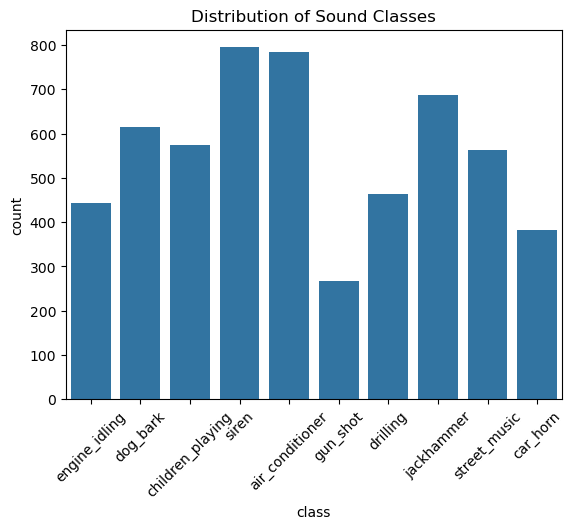

In [92]:
sns.countplot(data=df, x='class')
plt.title("Distribution of Sound Classes")
plt.xticks(rotation=45)
plt.show()

### Realism & Model Robustness & Prevent Over-fitting
- Simulate the measurement error or real-world variations that naturally occur in data collection process
- By adding a slight amount of random "noise" or "variability" to the decibel column

In [94]:
import numpy as np

# Add noise: mean=0, std=2 (you can adjust std for more/less variation)
df['decibel_noisy'] = df['decibel'] + np.random.normal(loc=0, scale=1.5, size=len(df))

# Clip to realistic decibel range (e.g., 60–130 dB)
df['decibel_noisy'] = df['decibel_noisy'].clip(lower=60, upper=130)

# Preview
df[['class', 'decibel', 'decibel_noisy']].head()

,class,decibel,decibel_noisy
0,engine_idling,75,75.272665
1,dog_bark,85,87.736524
2,children_playing,70,68.291580
3,siren,110,111.358048
4,air_conditioner,65,63.196147


## Models

### Decision Tree
- Predictors: type of noise, occurrence district, geological location, and time and day of noise occurring
- Dependent Variable: decibel_noisy (simulated real-world data)

In [96]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Encode categorical features
le_class = LabelEncoder()
le_district = LabelEncoder()
df['class'] = le_class.fit_transform(df['class'])
df['district'] = le_district.fit_transform(df['district'])

# Define features (X) and new target (y)
X = df[['class', 'district', 'latitude', 'longitude', 'hour', 'day']]
y = df['decibel_noisy']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Train
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Evaluate
mse_dt = np.mean((y_test - y_pred_dt) ** 2)
rmse_dt = np.sqrt(mse_dt)
mae_dt = np.mean(np.abs(y_test - y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("\nDecision Tree Metrics:")
print(f"MSE: {mse_dt:.2f}")
print(f"RMSE: {rmse_dt:.2f}")
print(f"MAE: {mae_dt:.2f}")
print(f"R² Score: {r2_dt:.3f}")


Decision Tree Metrics:
MSE: 4.84
RMSE: 2.20
MAE: 1.73
R² Score: 0.983


### Decision Tree Model Visualization
Two visualizations were created to assess the performance of the Decision Tree Regressor

- A scatter plot compared actual versus predicted decibel values, with a reference line indicating perfect predictions.
- A histogram displayed the distribution of residuals (errors), allowing evaluation of model bias and error spread.

These plots help diagnose prediction accuracy and potential model shortcomings.

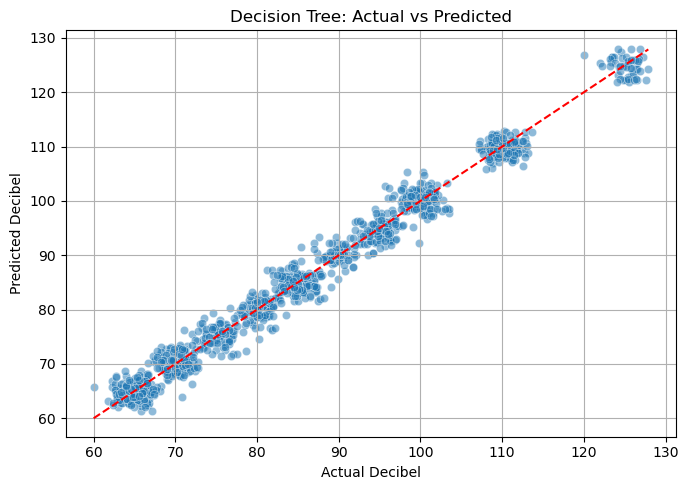

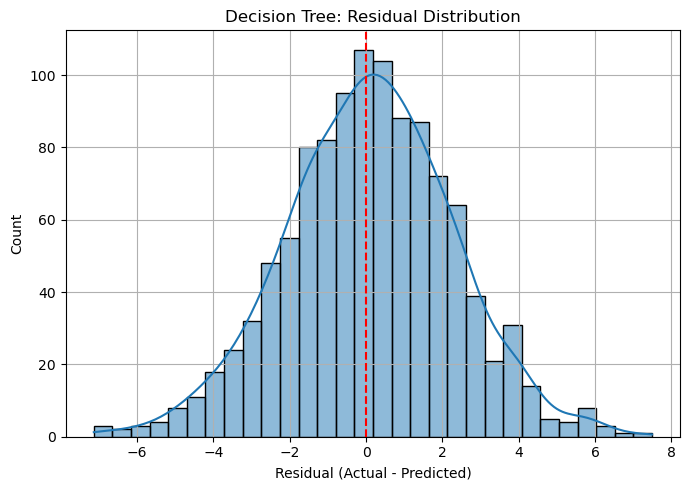

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred_dt, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Decibel")
plt.ylabel("Predicted Decibel")
plt.title("Decision Tree: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Residual Distribution Plot
residuals_dt = y_test - y_pred_dt
plt.figure(figsize=(7, 5))
sns.histplot(residuals_dt, kde=True, bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Decision Tree: Residual Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

### Random Forest Regression
A Random Forest Regressor was developed to predict noise levels (`decibel_noisy`) based on encoded categorical variables, geographic coordinates, and temporal features.\
After training and testing on an 80/20 data split, the model's performance was evaluated using MSE, RMSE, MAE, and R², providing insights into its prediction accuracy and error distribution.

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Encode categorical features
le_class = LabelEncoder()
le_district = LabelEncoder()
df['class'] = le_class.fit_transform(df['class'])
df['district'] = le_district.fit_transform(df['district'])


# Define features (X) and new target (y)
X = df[['class', 'district', 'latitude', 'longitude', 'hour', 'day']]
y = df['decibel_noisy']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf.predict(X_test)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_rf)
r2 = r2_score(y_test, y_pred_rf)

print("RF MSE:", mse)
print("RF RMSE:", rmse)
print("RF MAE:", mae)
print("RF R2 Score:", r2)

RF MSE: 2.924152760409905
RF RMSE: 1.710015426950852
RF MAE: 1.374267449044714
RF R2 Score: 0.9895536363759435


In [102]:
y_pred_rf = rf.predict(X_test)
y_pred_rf

array([100.30479619,  78.77377164, 100.86557341, ...,  89.53981533,
        80.80778038,  94.2724028 ])

### Random Forest Model Visualization
Two plots were generated to evaluate the Random Forest Regressor’s performance:

- A scatter plot comparing actual versus predicted decibel values, with a reference line indicating perfect predictions.
- A histogram illustrating the distribution of residuals (prediction errors), helping to assess model bias and the spread of errors.

These visual diagnostics provide insight into the model’s accuracy and error behavior.

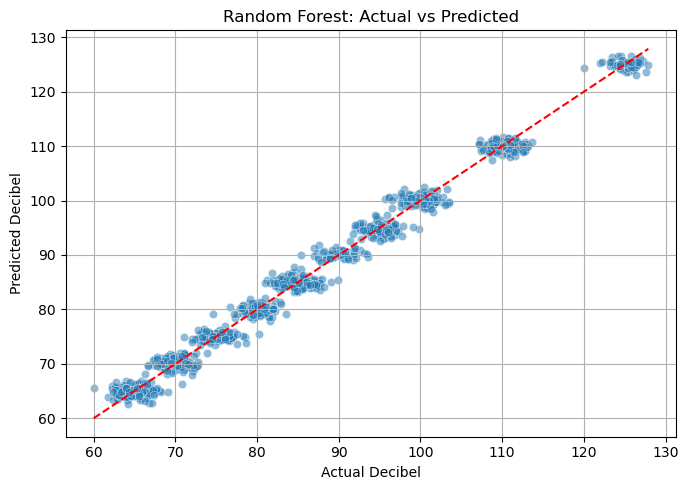

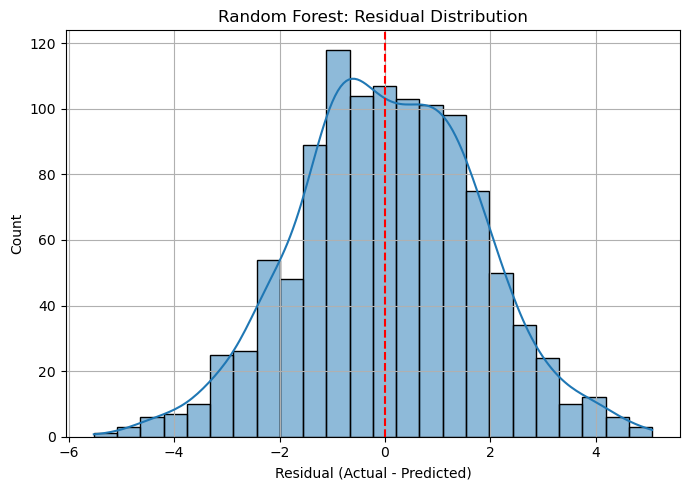

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Actual vs Predicted
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Decibel")
plt.ylabel("Predicted Decibel")
plt.title("Random Forest: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Residual Plot
residuals = y_test - y_pred_rf
plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Random Forest: Residual Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

### Support Vector Regression with Preprocessing Pipeline
A preprocessing pipeline was built to standardize numerical features and one-hot encode categorical variables. The processed dataset was then split into training and testing sets. A Support Vector Regressor (SVR) with an RBF kernel was trained on the transformed data and used to predict noise levels on the test set.

In [108]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X = df[['class', 'district', 'latitude', 'longitude', 'hour', 'day', 'salience']]
y = df['decibel_noisy']

# Assuming 'class' and 'district' are categorical
categorical = ['class', 'district']
numerical = ['hour', 'day', 'latitude', 'longitude', 'salience']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical),
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical)
])

X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

# Then train SVM
from sklearn.svm import SVR
model = SVR(kernel='rbf')
model.fit(X_train, y_train)
y_pred_svm = model.predict(X_test)

### Support Vector Regression Model Evaluation

In [110]:
# Evaluate
mse = mean_squared_error(y_test, y_pred_svm)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_svm)
r2 = r2_score(y_test, y_pred_svm)

print(f"SVR MSE: {mse:.2f}")
print(f"SVR RMSE: {rmse:.2f}")
print(f"SVR MAE: {mae:.2f}")
print(f"SVR R² Score: {r2:.3f}")

SVR MSE: 31.46
SVR RMSE: 5.61
SVR MAE: 3.08
SVR R² Score: 0.888


### Support Vector Regression Model Visualization
Visualizations were generated to evaluate the SVR model's predictions, including a scatter plot of actual versus predicted decibel values and a residual distribution plot to examine prediction errors and model bias.

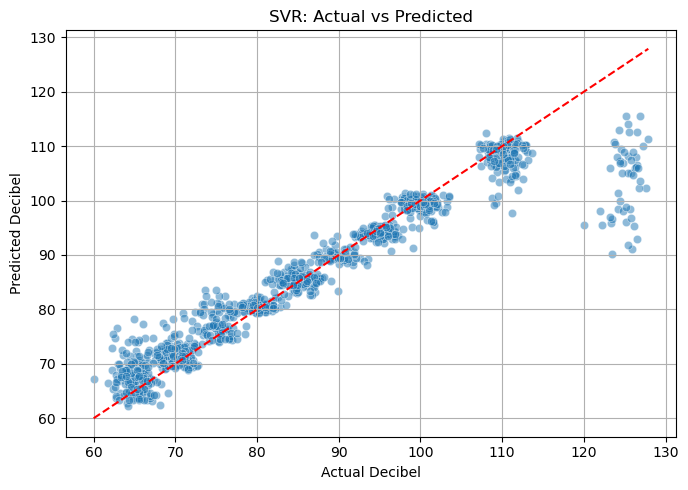

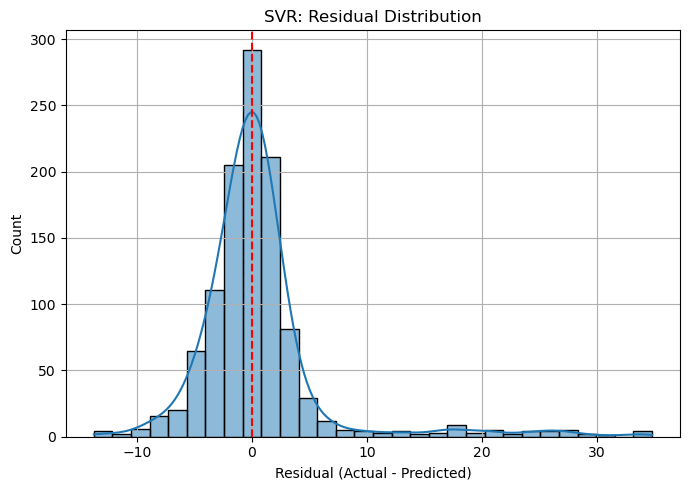

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred_svm, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Decibel")
plt.ylabel("Predicted Decibel")
plt.title("SVR: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Residual Distribution Plot
residuals = y_test - y_pred_svm
plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True, bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual (Actual - Predicted)")
plt.title("SVR: Residual Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

### LightGBM Regressor Model
A LightGBM Regressor was trained on the processed training data to predict noise levels. The model then generated predictions on the test set for further evaluation.

In [131]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred_lgbm = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000893 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 98
[LightGBM] [Info] Number of data points in the train set: 4456, number of used features: 25
[LightGBM] [Info] Start training from score 88.062859


C:\Users\Vivobook\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### LightGBM Model Evaluation
The LightGBM model's performance was evaluated using MSE, RMSE, MAE, and R² metrics to measure its prediction accuracy on the test set.

In [133]:
# Evaluate
mse = mean_squared_error(y_test, y_pred_lgbm)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_lgbm)
r2 = r2_score(y_test, y_pred_lgbm)

print(f"LightGBM MSE: {mse:.2f}")
print(f"LightGBM RMSE: {rmse:.2f}")
print(f"LightGBM MAE: {mae:.2f}")
print(f"LightGBM R² Score: {r2:.3f}")

LightGBM MSE: 2.41
LightGBM RMSE: 1.55
LightGBM MAE: 1.24
LightGBM R² Score: 0.991


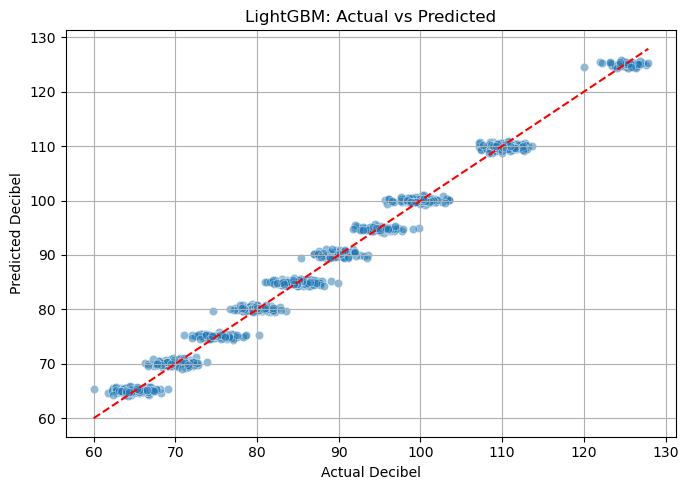

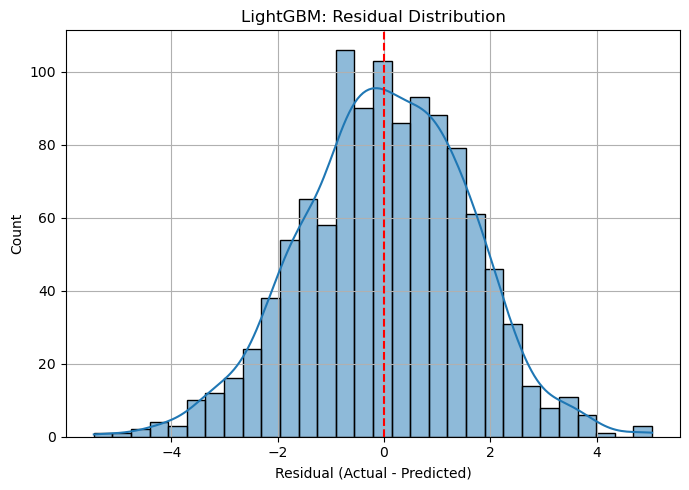

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Actual vs Predicted Plot
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred_lgbm, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Decibel")
plt.ylabel("Predicted Decibel")
plt.title("LightGBM: Actual vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Residual Distribution Plot
residuals = y_test - y_pred_lgbm
plt.figure(figsize=(7, 5))
sns.histplot(residuals, kde=True, bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual (Actual - Predicted)")
plt.title("LightGBM: Residual Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

## Final Model Comparison
Multiple regression models, including Random Forest, LightGBM, SVR, and Decision Tree, were evaluated and compared based on MSE, RMSE, MAE, and R² metrics. A summary table was created to highlight and rank model performance.

In [149]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# Train and predict for Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Train and predict for Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Dictionary of model predictions
predictions = {
    "Random Forest": y_pred_rf,
    "LightGBM": y_pred_lgbm,
    "SVR": y_pred_svm,
    "Decision Tree": y_pred_dt
}

# Compare models
results = []
for model_name, y_pred in predictions.items():
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R² Score": r2
    })

# Create DataFrame
comparison_df = pd.DataFrame(results).sort_values(by="R² Score", ascending=False).reset_index(drop=True)

# Display
print("\n Final Model Comparison:\n")
print(comparison_df)


 Final Model Comparison:

           Model        MSE      RMSE       MAE  R² Score
0       LightGBM   2.410794  1.552673  1.239426  0.991388
1  Random Forest   2.924153  1.710015  1.374267  0.989554
2  Decision Tree   4.949545  2.224757  1.782472  0.982318
3            SVR  31.462723  5.609164  3.078465  0.887601


### Bar chart of Model R² Scores

C:\Users\Vivobook\AppData\Local\Temp\ipykernel_28312\3476589022.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R² Score', y='Model', data=comparison_df, palette='viridis')


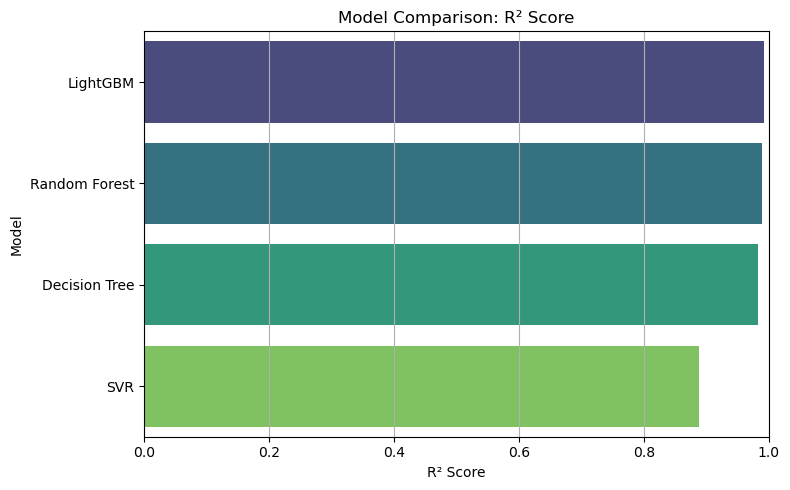

In [151]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(x='R² Score', y='Model', data=comparison_df, palette='viridis')
plt.title('Model Comparison: R² Score')
plt.xlim(0, 1)
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

### Bar chart of Model Error Metrics

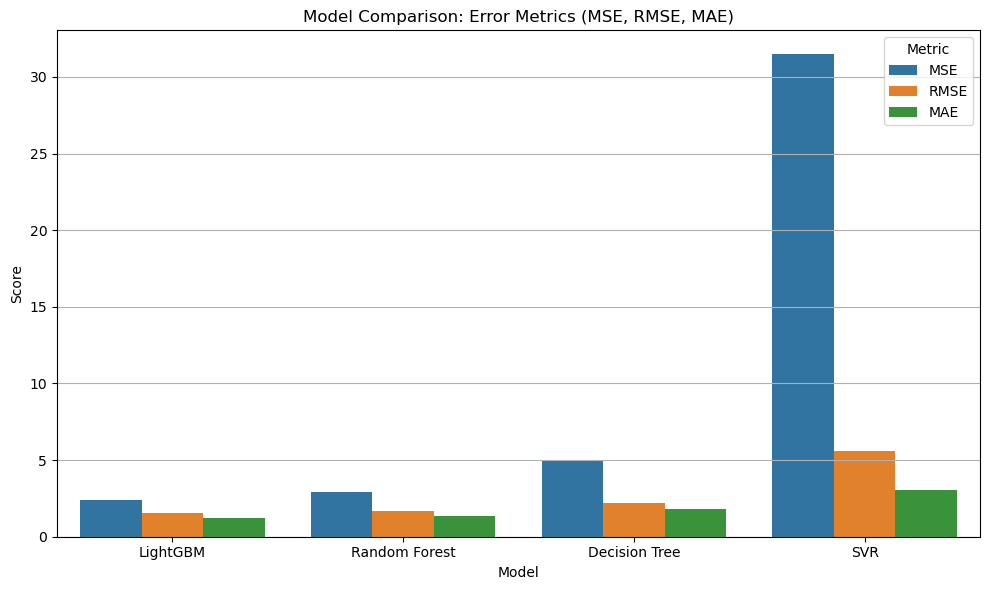

In [153]:
# Melt the DataFrame for easier plotting
metrics_melted = comparison_df.melt(id_vars='Model', value_vars=['MSE', 'RMSE', 'MAE'],
                                     var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_melted)
plt.title('Model Comparison: Error Metrics (MSE, RMSE, MAE)')
plt.ylabel('Score')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

### Heatmap of Model Evaluation Metrics

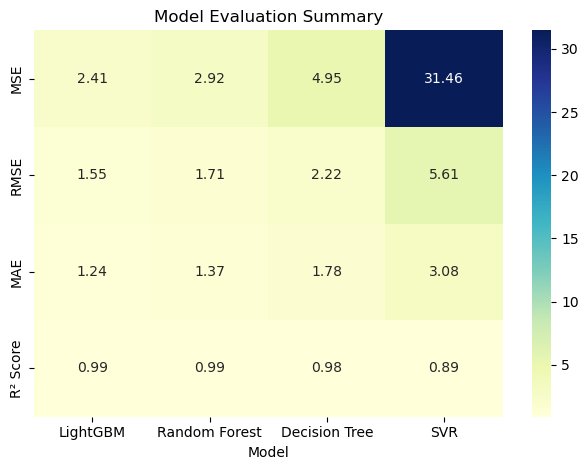

In [155]:
sns.heatmap(comparison_df.set_index('Model').T, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Model Evaluation Summary")
plt.tight_layout()
plt.show()

### Residual Distribution Comparison Across Models with box plot

C:\Users\Vivobook\AppData\Local\Temp\ipykernel_28312\1005106865.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Model", y="Residual", data=residuals_df_melted, palette="Set3")


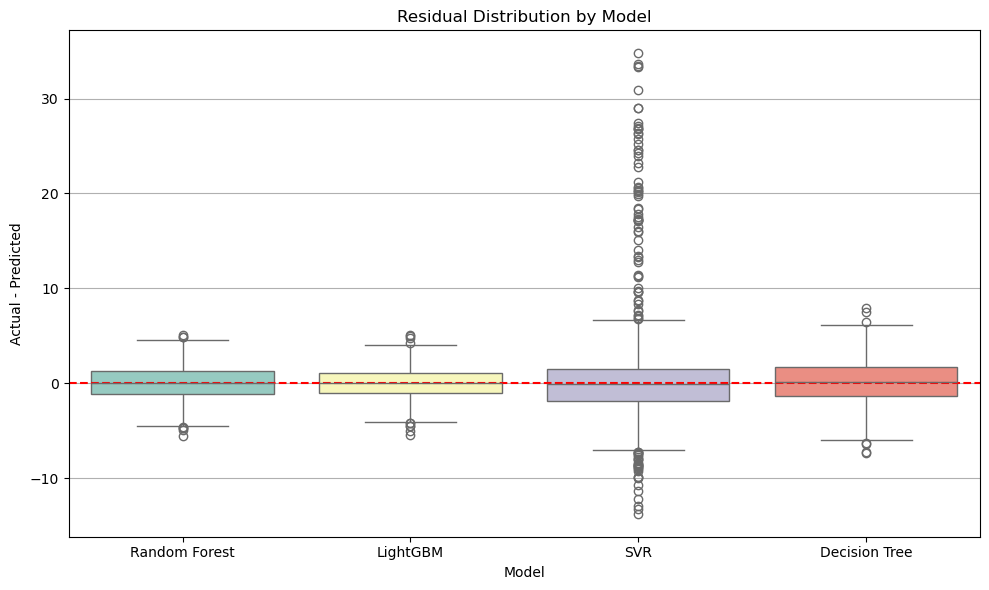

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Residuals for each model
residuals = {
    "Random Forest": y_test - y_pred_rf,
    "LightGBM": y_test - y_pred_lgbm,
    "SVR": y_test - y_pred_svm,
    "Decision Tree": y_test - y_pred_dt,
}

# Convert to long-form DataFrame
residuals_df = pd.DataFrame(residuals)
residuals_df_melted = residuals_df.melt(var_name="Model", value_name="Residual")

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x="Model", y="Residual", data=residuals_df_melted, palette="Set3")
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Distribution by Model")
plt.ylabel("Actual - Predicted")
plt.xlabel("Model")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

### Radar Chart of Normalized Model Performance

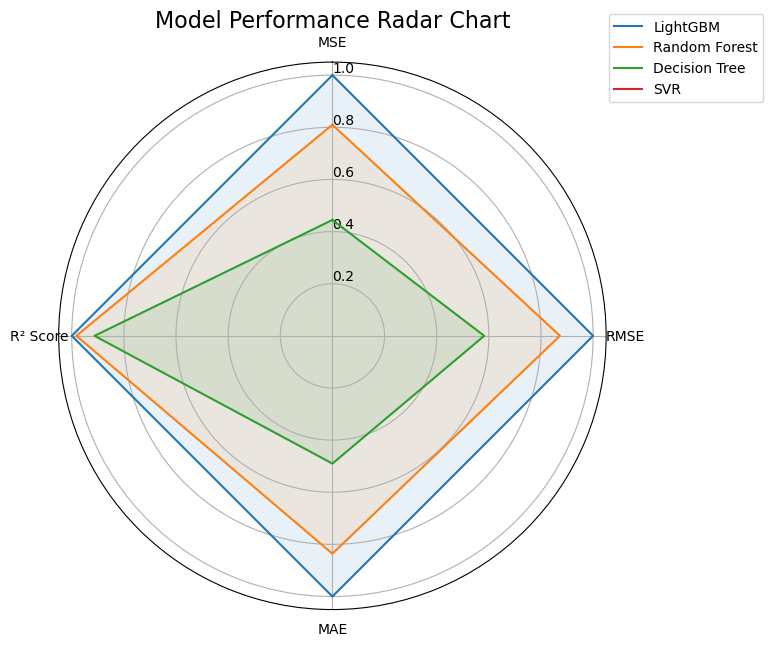

In [172]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# STEP 1: Invert error metrics (so higher = better)
df_norm = comparison_df.copy()
for col in ['MSE', 'RMSE', 'MAE']:
    df_norm[col] = 1 / df_norm[col]

# STEP 2: Normalize all metrics to 0–1 range
df_norm.iloc[:, 1:] = df_norm.iloc[:, 1:].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

# STEP 3: Prepare for radar chart
labels = df_norm.columns[1:]
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close loop

# STEP 4: Plot radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i in range(len(df_norm)):
    values = df_norm.iloc[i, 1:].tolist()
    values += values[:1]  # close loop
    ax.plot(angles, values, label=df_norm.iloc[i, 0])
    ax.fill(angles, values, alpha=0.1)

# STEP 5: Customize and show
ax.set_title("Model Performance Radar Chart", size=16)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_rlabel_position(0)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

## Final Model Comparison Wrap-Up and Conclusion

After evaluating four different regression models — LightGBM, Random Forest, Decision Tree, and SVR — across multiple metrics (MSE, RMSE, MAE, R² Score), the results are summarized as follows:

| Model           | MSE    | RMSE   | MAE    | R² Score |
|-----------------|--------|--------|--------|----------|
| LightGBM        | 2.41   | 1.55   | 1.24   | 0.991    |
| Random Forest   | 2.92   | 1.71   | 1.37   | 0.990    |
| Decision Tree   | 4.95   | 2.22   | 1.78   | 0.982    |
| SVR             | 31.46  | 5.61   | 3.08   | 0.888    |

**Key Findings:**
- **LightGBM**: achieved the best overall performance with the lowest error metrics (MSE, RMSE, MAE) and the highest R² Score (~0.991), indicating it predicted noise levels very accurately.
- **Random Forest**: also performed strongly, slightly trailing LightGBM, with high R² and low error rates.
- **Decision Tree**: had moderately good performance but showed higher errors compared to LightGBM and Random Forest.
- **SVR**: showed noticeably worse performance compared to tree-based models, with a significantly higher MSE, RMSE, and MAE, and a lower R² Score (~0.888).

**Visual Insights:**
- The **R² score bar plot** showed LightGBM and Random Forest leading by a small margin, while SVR lagged behind.
- The **error metrics grouped bar plot** highlighted SVR’s much higher MSE compared to others.
- The **heatmap** made it easy to spot LightGBM's consistently superior performance across all metrics.
- The **residual box plot** revealed that LightGBM and Random Forest had tighter and more symmetric residual distributions, while SVR had larger residual variance and more outliers.
- The **radar chart** visually emphasized LightGBM’s dominance, closely followed by Random Forest across all normalized metrics.

**Conclusion:**
- **LightGBM** is the most effective model for predicting noise levels in this case, balancing low prediction error and strong generalization.
- **Random Forest** is a very close second and a strong alternative if ensemble tree methods are preferred.
- **Decision Tree** could be considered for simpler model requirements but at the cost of accuracy.
- **SVR** is not recommended for this dataset given its much poorer predictive performance relative to the others.

Moving forward, LightGBM could be further fine-tuned (e.g., through hyperparameter optimization) to potentially achieve even better results.

---
